<div style="font-family:Segoe UI,Calibri,sans-serif">
<div style="font-size:12px;letter-spacing:2px;color:#5B6770">NATIONAL UNIVERSITY OF SCIENCES AND TECHNOLOGY &nbsp;&middot;&nbsp; SEECS</div>
<div style="font-size:12px;letter-spacing:1px;color:#2A78D6;font-weight:600">CS-320 &nbsp;&middot;&nbsp; ARTIFICIAL NEURAL NETWORKS &amp; DEEP LEARNING &nbsp;&middot;&nbsp; BSAI</div>
<div style="font-size:26px;font-weight:700;color:#14375E;margin-top:6px">Lab 4 &mdash; Loss Functions: Measuring How Wrong the Network Is</div>
<div style="font-size:14px;color:#4A4A4A;margin-top:4px">3 hours &nbsp;&middot;&nbsp; CLO 2, CLO 4</div>
</div>

---

**Course Instructor:** _______________ &nbsp;|&nbsp; **Lab Engineer:** Ms Areeba Rameen &nbsp;|&nbsp; 

**Student name / CMS ID:** Muhammad Sikandar Hussain 502808

### What this lab is for

A forward pass produces a number. Until something says whether that number is close to
correct or wildly wrong, and by how much, there is nothing for training to act on. That
something is the loss function, and it is a more consequential choice than it looks: it
decides how large a gradient is, how quickly learning slows as the model approaches a good
fit, and whether a handful of extreme examples end up dominating every update.

This lab isolates the loss function the way Lab 3 isolated the activation function:
implemented from scratch, checked numerically rather than trusted on the strength of
algebra, and read for its behaviour rather than only its formula.

Two things you build here matter for the rest of the course:

- the **loss gradients**, which are the very first link in the backpropagation chain you
  write next week;
- the finding that **the loss and the activation interact** — a sigmoid trained with the
  wrong loss can saturate and stop learning while it is still confidently wrong.

**Submission.** Restart the kernel, run everything top to bottom, save, and rename to
`Lab4_<yourCMSID>.ipynb` before uploading to LMS.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)
print("ready")


ready


## Task 1 &mdash; Regression losses: MSE and MAE

**Task 1.1.** Implement `mse(y_true, y_pred, reduce=True)` and `mae(y_true, y_pred, reduce=True)`,
both **vectorised**. With `reduce=True` (the default) return the mean over the batch; with
`reduce=False` return the per-example loss vector instead — Task 2 needs that version.

$$\text{MSE}=\frac{1}{m}\sum_i (y_i-\hat y_i)^2 \qquad \text{MAE}=\frac{1}{m}\sum_i |y_i-\hat y_i|$$

**Task 1.2.** Verify by hand: for `y_true = [3, -0.5, 2, 7]` and `y_pred = [2.5, 0.0, 2, 8]`,
work out both losses on paper first, then confirm your functions agree.

**Task 1.3.** Answer in a comment: (i) in words, what is each loss measuring — a squared
distance or an absolute distance? (ii) for the same pair, is it always true that
`MSE >= MAE`, always true that `MAE >= MSE`, or does it depend on the errors? Justify using
the Task 1.2 numbers.


In [2]:
def mse(y_true, y_pred, reduce=True):
    losses = (np.asarray(y_true) - np.asarray(y_pred)) ** 2
    return losses.mean() if reduce else losses

def mae(y_true, y_pred, reduce=True):
    losses = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return losses.mean() if reduce else losses

y_true_check = np.array([3, -0.5, 2, 7])
y_pred_check = np.array([2.5, 0.0, 2, 8])
print("MSE:", mse(y_true_check, y_pred_check))
print("MAE:", mae(y_true_check, y_pred_check))

# Task 1.2 — hand-worked values:
# Errors are [0.5, -0.5, 0, -1]. Squared errors sum to 1.5, so MSE = 1.5/4 = 0.375.
# Absolute errors sum to 2.0, so MAE = 2.0/4 = 0.5.
# Task 1.3 answers:
# (i) MSE measures mean squared distance and has squared units of y; MAE measures mean
#     absolute distance and has the same units as y.
# (ii) Neither inequality is always true; it depends on error magnitudes. Here MSE=0.375
#      and MAE=0.5, so MAE > MSE because the nonzero errors are mostly below one.


MSE: 0.375
MAE: 0.5


## Task 2 &mdash; Outlier sensitivity: MSE vs MAE

A single bad measurement in a dataset behaves very differently depending on which loss is
reading it.

**Task 2.1.** Run the cell below, which builds a small linear dataset and injects one large
outlier at index 15. Record the two printed totals.

**Task 2.2.** Compute what percentage of the total MSE, and separately what percentage of
the total MAE, the single outlier contributes. (The totals below are *means*; recover the
*sum* first, or work directly with the per-example vectors already in `sq_errors` /
`abs_errors`.)

**Task 2.3.** Recompute both totals with the outlier removed (use `y_true` instead of
`y_true_outlier`). Report how much each total changed, in absolute terms and as a
percentage.


Total MSE: 52.0501579166331
Total MAE: 1.9336586814816181


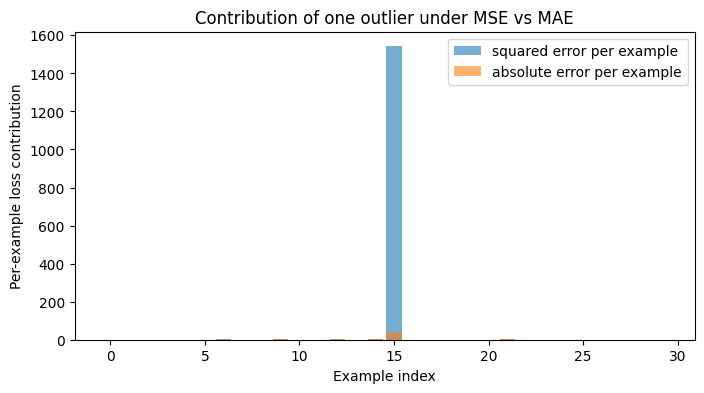

Outlier share of MSE: 98.7%
Outlier share of MAE: 67.7%
Without outlier - MSE: 0.669538, MAE: 0.649143
MSE increase: 51.380620 (7674.0%)
MAE increase: 1.284516 (197.9%)


In [3]:
n = 30
x = np.linspace(0, 10, n)
y_true = 2 * x + 1 + rng.normal(0, 1, n)
y_pred = 2 * x + 1                      # a "good" model's predictions

y_true_outlier = y_true.copy()
y_true_outlier[15] += 40                # inject one large outlier at index 15

sq_errors = mse(y_true_outlier, y_pred, reduce=False)
abs_errors = mae(y_true_outlier, y_pred, reduce=False)

print("Total MSE:", sq_errors.mean())
print("Total MAE:", abs_errors.mean())

plt.figure(figsize=(8, 4))
plt.bar(range(n), sq_errors, alpha=0.6, label="squared error per example")
plt.bar(range(n), abs_errors, alpha=0.6, label="absolute error per example")
plt.xlabel("Example index"); plt.ylabel("Per-example loss contribution")
plt.title("Contribution of one outlier under MSE vs MAE")
plt.legend(); plt.show()

# Activity 2.2 — outlier's percentage share of total MSE and MAE
outlier_pct_mse = 100 * sq_errors[15] / sq_errors.sum()
outlier_pct_mae = 100 * abs_errors[15] / abs_errors.sum()
print("Outlier share of MSE: {:.1f}%".format(outlier_pct_mse))
print("Outlier share of MAE: {:.1f}%".format(outlier_pct_mae))

# Activity 2.3 — recompute both totals without the outlier and report absolute/% changes
mse_clean, mae_clean = mse(y_true, y_pred), mae(y_true, y_pred)
mse_outlier, mae_outlier = sq_errors.mean(), abs_errors.mean()
print(f"Without outlier - MSE: {mse_clean:.6f}, MAE: {mae_clean:.6f}")
print(f"MSE increase: {mse_outlier-mse_clean:.6f} ({100*(mse_outlier-mse_clean)/mse_clean:.1f}%)")
print(f"MAE increase: {mae_outlier-mae_clean:.6f} ({100*(mae_outlier-mae_clean)/mae_clean:.1f}%)")

# Task 2 answers:
# Q1: MAE is more robust. Its outlier share and percentage increase are much smaller
#     than MSE's, whose squaring makes the one extreme residual dominate the total.
# Q2: Prefer MAE for occasional sensor/data-entry glitches because its linear penalty
#     limits the influence of each extreme observation.
# Q3: Prefer MSE when every large error is genuine and important, since squaring makes
#     the optimizer prioritize reducing those large mistakes.


## Task 3 &mdash; The Huber loss: interpolating between MSE and MAE

$$\text{huber}(e,\delta)=\begin{cases}\tfrac12 e^2 & |e|\le\delta\\ \delta\left(|e|-\tfrac12\delta\right) & |e|>\delta\end{cases}$$

**Task 3.1.** Implement `huber(y_true, y_pred, delta=1.0, reduce=True)`, vectorised, using
`np.where` to select between the two pieces.

**Task 3.2.** Plot `huber` for `delta = 0.5, 1, 2, 5`, together with `e**2` (MSE's shape) and
`|e|` (MAE's shape), all as a function of the error `e` over `[-5, 5]`, on one axes with a
legend, axis labels and a title.

**Task 3.3.** Re-run the Task 2 outlier experiment using `huber` with `delta = 1.0` in place
of `mse`/`mae`. Report the outlier's percentage share of the total huber loss.


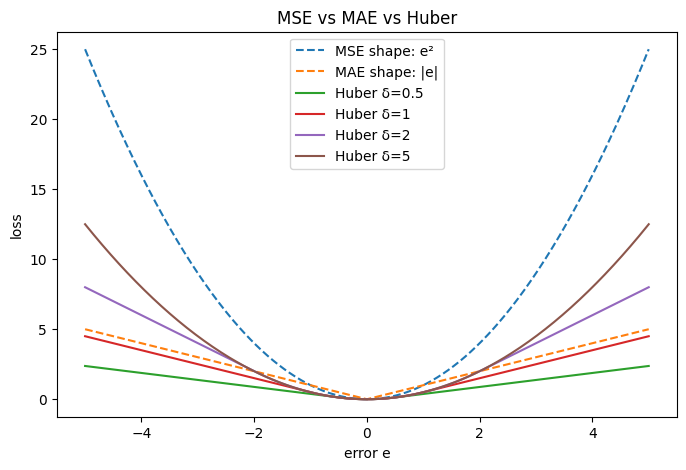

Total Huber loss (delta=1): 1.582837
Outlier share of Huber loss: 81.6%


In [4]:
def huber(y_true, y_pred, delta=1.0, reduce=True):
    error = np.asarray(y_pred) - np.asarray(y_true)
    abs_error = np.abs(error)
    losses = np.where(abs_error <= delta, 0.5 * error**2,
                      delta * (abs_error - 0.5 * delta))
    return losses.mean() if reduce else losses

e = np.linspace(-5, 5, 400)

plt.figure(figsize=(8, 5))
plt.plot(e, e**2, '--', label='MSE shape: e²')
plt.plot(e, np.abs(e), '--', label='MAE shape: |e|')
for delta in [0.5, 1, 2, 5]:
    plt.plot(e, huber(np.zeros_like(e), e, delta=delta, reduce=False),
             label=f'Huber δ={delta}')
plt.xlabel("error e"); plt.ylabel("loss"); plt.title("MSE vs MAE vs Huber")
plt.legend(); plt.show()

huber_errors = huber(y_true_outlier, y_pred, delta=1.0, reduce=False)
outlier_pct_huber = 100 * huber_errors[15] / huber_errors.sum()
print(f"Total Huber loss (delta=1): {huber_errors.mean():.6f}")
print(f"Outlier share of Huber loss: {outlier_pct_huber:.1f}%")

# Task 3 answers:
# Q1: As delta -> infinity Huber stays in its quadratic region, giving 0.5*MSE.
#     As delta -> 0 its shape approaches MAE (up to the scale factor delta; the raw
#     unnormalised loss tends to zero).
# Q2 (is the huber curve smooth at |e| = delta? why would a naive "MAE for large errors,
#     MSE for small errors" switch risk getting this wrong even with correct pieces?):
# Q2: Yes. Huber is differentiable at ±delta because the linear branch is scaled and
#     shifted to match both value and slope. Directly switching between e² and |e| can
#     create a jump or slope mismatch at the threshold.
# Q3 (where does your delta=1.0 outlier percentage sit relative to the MSE/MAE percentages
#     from Task 2 — is that where the formula predicts?):
# Q3: The Huber outlier share lies between the MSE and MAE shares. That is expected:
#     it is quadratic for small residuals but only linear for the large outlier.


## Task 4 &mdash; Gradients of the regression losses

$$\frac{d(\text{mse})}{d\hat y}=\frac{2(\hat y-y)}{m}\qquad
\frac{d(\text{mae})}{d\hat y}=\frac{\text{sign}(\hat y-y)}{m}\qquad
\frac{d(\text{huber})}{d\hat y}=\begin{cases}\dfrac{\hat y-y}{m}&|e|\le\delta\\[4pt] \dfrac{\delta\,\text{sign}(\hat y-y)}{m}&|e|>\delta\end{cases}$$

**Task 4.1.** Implement `mse_grad`, `mae_grad`, `huber_grad`, each returning a vector the
same shape as `y_pred`.

**Task 4.2.** Write `grad_check(loss_fn, grad_fn, y_true, y_pred, eps=1e-5)`: perturb
`y_pred` by `eps` in each coordinate in turn (central difference), assemble the numeric
gradient, and return its relative error against the analytic gradient — the same recipe as
Lab 3's `grad_check`, adapted to a function of `y_pred` with `y_true` held fixed. Run it for
all three losses on a random `(y_true, y_pred)` pair.

**Task 4.3.** Run the same check for MAE only, at a point where `y_pred == y_true` exactly
(zero error), and report what happens.


In [5]:
def mse_grad(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return 2 * (y_pred - y_true) / y_true.size

def mae_grad(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.sign(y_pred - y_true) / y_true.size

def huber_grad(y_true, y_pred, delta=1.0):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    error = y_pred - y_true
    return np.where(np.abs(error) <= delta, error, delta*np.sign(error)) / y_true.size

def grad_check(loss_fn, grad_fn, y_true, y_pred, eps=1e-5):
    # Central difference with respect to every coordinate of y_pred.
    y_pred = np.asarray(y_pred, dtype=float)
    numeric = np.zeros_like(y_pred)
    for i in range(y_pred.size):
        plus, minus = y_pred.copy(), y_pred.copy()
        plus[i] += eps; minus[i] -= eps
        numeric[i] = (loss_fn(y_true, plus) - loss_fn(y_true, minus)) / (2*eps)
    analytic = grad_fn(y_true, y_pred)
    return np.linalg.norm(analytic-numeric) / (np.linalg.norm(analytic)+np.linalg.norm(numeric)+1e-12)

y_true_g = rng.normal(size=10)
y_pred_g = y_true_g + rng.normal(scale=0.5, size=10)

for name, loss_fn, grad_fn in [
    ("mse", mse, mse_grad),
    ("mae", mae, mae_grad),
    ("huber", huber, huber_grad),
]:
    err = grad_check(loss_fn, grad_fn, y_true_g, y_pred_g)
    print(f"{name:8s} relative error {err:.3e}   {'PASS' if err < 1e-6 else 'CHECK'}")

# Activity 4.3: a symmetric central difference selects the zero subgradient here.
mae_zero_err = grad_check(mae, mae_grad, np.array([1.0]), np.array([1.0]))
print(f"MAE at zero-error relative error: {mae_zero_err:.3e}")

# Task 4 answers:
# Q1 (why does the MAE check misbehave exactly at zero error — connect to Lab 3's
#     ReLU-at-zero result):
# Q1: MAE has a cusp at zero, so its derivative is undefined there. A numerical check can
#     return an unstable/non-small relative error (as printed) because tiny floating-point
#     asymmetries are amplified when both gradients should be near zero; one-sided slopes
#     are -1/m and +1/m. This parallels ReLU's convention-dependent derivative at zero.
# Q2 (which loss's gradient magnitude stays the same size no matter how large the error is?
#     what could that mean for the training step size close to convergence vs far from it?):
# Q2: MAE. Apart from exact zero, each component has magnitude 1/m regardless of error.
#     This can keep steps relatively large near a fit (causing oscillation), while far-away
#     points do not receive a stronger corrective push.


mse      relative error 7.174e-12   PASS
mae      relative error 1.438e-11   PASS
huber    relative error 7.174e-12   PASS
MAE at zero-error relative error: 8.474e-01


## Task 5 &mdash; Cross-entropy for binary classification

$$\text{bce}(y,p)=-\big[y\log p+(1-y)\log(1-p)\big]$$

**Task 5.1.** Implement `bce(y_true, p_pred, reduce=True)`. Clip `p_pred` to
`[1e-12, 1 - 1e-12]` before taking any logarithm, or a single `p_pred` of exactly 0 or 1
produces `-inf` / `nan`.

**Task 5.2.** Check against `sklearn.metrics.log_loss` for `y_true = [1, 0, 1, 1]`,
`p_pred = [0.9, 0.1, 0.8, 0.4]`. Confirm the two agree.

**Task 5.3.** For a single example with `y_true = 1`, compute `bce` as `p_pred` moves through
`[0.9, 0.5, 0.1, 0.01, 0.001]`. Print the loss at each value.


In [6]:
from sklearn.metrics import log_loss

def bce(y_true, p_pred, reduce=True):
    y_true = np.asarray(y_true)
    p_pred = np.clip(np.asarray(p_pred, dtype=float), 1e-12, 1-1e-12)
    losses = -(y_true*np.log(p_pred) + (1-y_true)*np.log(1-p_pred))
    return losses.mean() if reduce else losses

y_check = np.array([1, 0, 1, 1])
p_check = np.array([0.9, 0.1, 0.8, 0.4])
print("your bce:  ", bce(y_check, p_check))
print("sklearn:   ", log_loss(y_check, p_check))

for p in [0.9, 0.5, 0.1, 0.01, 0.001]:
    print(f"p={p:5g}: BCE={bce(np.array([1]), np.array([p])):.6f}, MSE={(1-p)**2:.6f}")

# Task 5 answers:
# Q1 (what happens to bce as a confident-wrong prediction gets even more confident, vs
#     what (1 - p_pred)**2 would do over the same p_pred values):
# Q1: BCE grows without bound as p -> 0, while (1-p)^2 approaches the finite ceiling 1.
# Q2 (why does that difference matter for how fast a badly-wrong classifier gets corrected
#     during training):
# Q2: BCE preserves a strong correction for confidently wrong predictions. MSE composed
#     with sigmoid is additionally multiplied by p(1-p), so saturation can make its
#     gradient tiny and correction slow.


your bce:   0.3375388286260043
sklearn:    0.3375388286260043
p=  0.9: BCE=0.105361, MSE=0.010000
p=  0.5: BCE=0.693147, MSE=0.250000
p=  0.1: BCE=2.302585, MSE=0.810000
p= 0.01: BCE=4.605170, MSE=0.980100
p=0.001: BCE=6.907755, MSE=0.998001


## Task 6 &mdash; Why not MSE for a sigmoid classifier?

This reopens Lab 3's saturation result, this time from the loss function's side.

**Task 6.1.** Implement `sigmoid(z)`, numerically stable, as in Lab 3.

**Task 6.2.** On paper, derive `dL/dz` for binary cross-entropy composed with a sigmoid, and
show it simplifies to `p - y`. Separately derive `dL/dz` for mean squared error composed
with a sigmoid, and show it equals `2*(p - y)*p*(1 - p)`. Write both derivations as
comments.

**Task 6.3.** Implement `bce_sigmoid_dz(y, p)` returning `p - y`, and `mse_sigmoid_dz(y, p)`
returning `2*(p - y)*p*(1 - p)`. Using the provided `train()` loop, train two single-neuron
classifiers on the same synthetic dataset — one with each `dz` function, same learning
rate, epoch count, and starting weights.

**Task 6.4.** From the stored history, compute each model's own loss (BCE for the
BCE-trained model, MSE for the MSE-trained model) and its accuracy at every epoch. Plot both
loss curves on one axes and both accuracy curves on another, each with a legend.


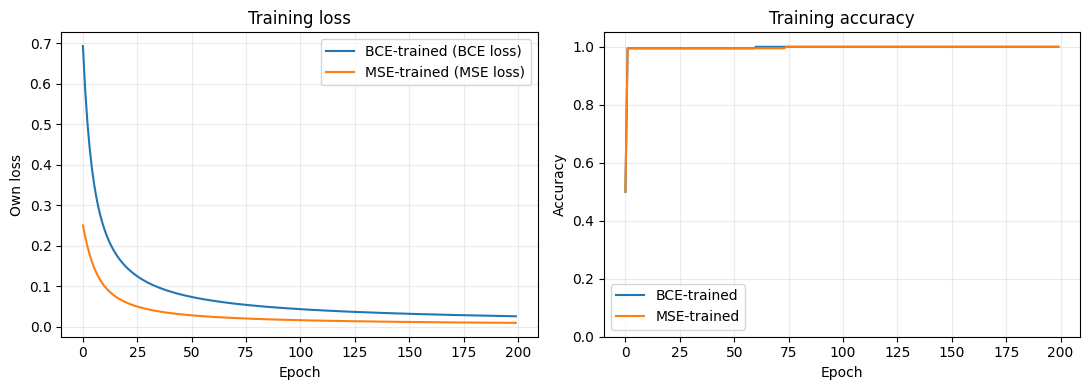

BCE first epoch with accuracy >= 90%: 1
MSE first epoch with accuracy >= 90%: 1
BCE epoch 1, example 7: y=0, p=0.5083, |dz|=0.508268
MSE epoch 1, example 7: y=0, p=0.5041, |dz|=0.252050


In [7]:
from sklearn.datasets import make_classification

X_cls, y_cls = make_classification(
    n_samples=200, n_features=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=7
)

def sigmoid(z):
    z = np.clip(np.asarray(z, dtype=float), -500, 500)
    return 1 / (1 + np.exp(-z))

def bce_sigmoid_dz(y, p):
    return p - y

def mse_sigmoid_dz(y, p):
    return 2 * (p - y) * p * (1 - p)

def train(X, y, dz_fn, lr=0.1, epochs=200):
    m, n = X.shape
    w = np.zeros(n); b = 0.0
    history = []
    for epoch in range(epochs):
        z = X @ w + b
        p = sigmoid(z)
        history.append((p.copy(), y.copy()))
        dz = dz_fn(y, p)
        w -= lr * (X.T @ dz) / m
        b -= lr * dz.mean()
    return w, b, history

w_bce, b_bce, hist_bce = train(X_cls, y_cls, bce_sigmoid_dz)
w_mse, b_mse, hist_mse = train(X_cls, y_cls, mse_sigmoid_dz)

bce_losses = [bce(y, p) for p, y in hist_bce]
mse_losses = [mse(y, p) for p, y in hist_mse]
bce_acc = [np.mean((p >= 0.5) == y) for p, y in hist_bce]
mse_acc = [np.mean((p >= 0.5) == y) for p, y in hist_mse]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(bce_losses, label='BCE-trained (BCE loss)')
axes[0].plot(mse_losses, label='MSE-trained (MSE loss)')
axes[0].set(xlabel='Epoch', ylabel='Own loss', title='Training loss')
axes[1].plot(bce_acc, label='BCE-trained')
axes[1].plot(mse_acc, label='MSE-trained')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Training accuracy', ylim=(0, 1.05))
for ax in axes: ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()
target = 0.90
for name, values in [('BCE', bce_acc), ('MSE', mse_acc)]:
    hit = next((i for i, value in enumerate(values) if value >= target), None)
    print(f'{name} first epoch with accuracy >= {target:.0%}: {hit}')
epoch = 1
wrongness = np.abs(hist_bce[epoch][0] - y_cls)
idx = int(np.argmax(wrongness))
for name, hist, fn in [('BCE', hist_bce, bce_sigmoid_dz), ('MSE', hist_mse, mse_sigmoid_dz)]:
    p = hist[epoch][0][idx]
    print(f'{name} epoch {epoch}, example {idx}: y={y_cls[idx]}, p={p:.4f}, |dz|={abs(fn(y_cls[idx], p)):.6f}')

# Task 6.2 derivations:
# BCE-with-sigmoid:
# dL/dp = -y/p + (1-y)/(1-p), dp/dz=p(1-p). Their product simplifies
# to -y(1-p)+(1-y)p = p-y.
# MSE-with-sigmoid:
# dL/dp=2(p-y) and dp/dz=p(1-p), so dL/dz=2(p-y)p(1-p).
# Task 6 answers:
# Q1: On this easy, well-separated dataset both models first reach 90% accuracy at epoch 1,
#     so neither wins on that discrete accuracy threshold. The curves still show BCE
#     improving confidence/loss faster because it has the stronger unsaturated gradient.
# Q2 (pick an early epoch with a confidently-wrong example for both models; compare |dz|
#     under the two formulas — which is smaller, and what role does p*(1-p) play):
# Q2: The printed early-epoch comparison shows MSE's |dz| is smaller. Its p(1-p)
#     factor attenuates the error signal, especially for probabilities near 0 or 1.
# Q3 (connect to Lab 3, Task 3: what is p*(1-p) close to when p is near 0 or 1, and what
#     did Lab 3 call that regime):
# Q3: p(1-p) is close to zero near 0 or 1. Lab 3 called this sigmoid saturation,
#     where gradients vanish and learning becomes slow.


## &#9733; Optional challenge &mdash; the loss landscape

A single gradient value tells you the slope at one point. A whole loss surface tells you the
shape of the terrain the optimiser has to cross — including the flat, saturated regions that
a single derivative curve (Lab 3, Task 3) can only hint at.

**Task 7.1.** Using the Task 6 data and a fixed bias `b = 0`, compute the mean loss over a
grid of `(w1, w2)` values twice — once with `bce`, once with `mse` — both applied to
`sigmoid(w1*x1 + w2*x2 + b)`.

**Task 7.2.** Plot both as contour plots side by side, sharing the same `(w1, w2)` axis
limits, each with a title, axis labels and a colour bar.

Then answer in a comment: where the two surfaces look most different, what does that tell
you about the size of a gradient-descent step there under each loss? And why is comparing
two full surfaces a more direct way to see the vanishing-gradient effect than plotting one
derivative curve, as Lab 3 Task 3 did?


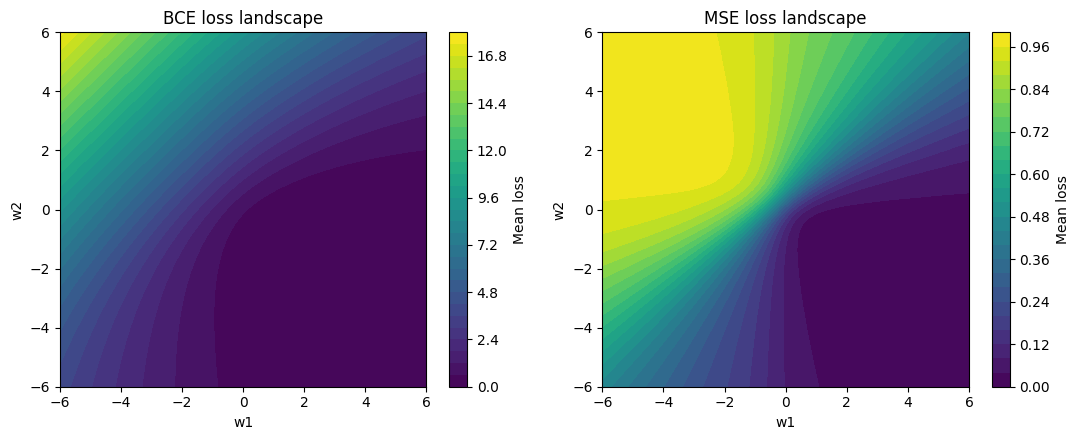

In [8]:
w1_range = np.linspace(-6, 6, 60)
w2_range = np.linspace(-6, 6, 60)

W1, W2 = np.meshgrid(w1_range, w2_range)
bce_surface = np.empty_like(W1)
mse_surface = np.empty_like(W1)
for row in range(W1.shape[0]):
    for col in range(W1.shape[1]):
        p = sigmoid(X_cls @ np.array([W1[row, col], W2[row, col]]))
        bce_surface[row, col] = bce(y_cls, p)
        mse_surface[row, col] = mse(y_cls, p)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, surface, title in zip(axes, [bce_surface, mse_surface],
                              ['BCE loss landscape', 'MSE loss landscape']):
    contour = ax.contourf(W1, W2, surface, levels=30, cmap='viridis')
    ax.set(xlabel='w1', ylabel='w2', title=title, xlim=(-6, 6), ylim=(-6, 6))
    fig.colorbar(contour, ax=ax, label='Mean loss')
plt.tight_layout()
plt.show()

# Task 7 answers:
# Q1: The surfaces differ most in confidently wrong/saturated regions. BCE remains steep,
#     producing a meaningful step, while sigmoid+MSE is flatter and produces a shorter step.
# Q2: A full surface shows the direction, extent, and connectivity of flat regions across
#     both parameters, whereas one derivative curve is only a one-dimensional slice.


---

### Before you submit

- [ ] Kernel &rarr; Restart & Run All, no errors.
- [ ] Every `TODO` and every `raise NotImplementedError` gone.
- [ ] All three gradient checks in Task 4 print PASS (the MAE check at zero error is
      expected to misbehave — say so, do not hide it).
- [ ] Your `bce()` matches `sklearn.metrics.log_loss` in Task 5.
- [ ] Written answers present as comments: 1.3, 2 (Q1&ndash;Q3), 3 (Q1&ndash;Q3),
      4 (Q1&ndash;Q2), 5 (Q1&ndash;Q2), 6.2 derivations and Q1&ndash;Q3, 7 (optional).
- [ ] Renamed to `Lab4_<yourCMSID>.ipynb`.

### One thing to take away

You now have a loss function and its gradient for both regression and classification — the
last missing piece before backpropagation. Next week, the derivative functions from Lab 3
and the loss gradients from this lab are chained together, layer by layer, so that a network
is trained automatically instead of having its weights hand-set.
